# Exploratory Data Analysis (EDA)

In this notebook, we explore the cleaned housing dataset to understand feature distributions, relationships between variables, and key factors influencing house prices.

The goal of this analysis is to identify important patterns and insights that can guide feature engineering and modeling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Data/processed/cleaned_train.csv')
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,12.247699
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,12.109016
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,12.317171
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,12.429220
5,6,50,RL,85.0,14115,Pave,IR1,Lvl,AllPub,Inside,...,0,320,0,0,700,10,2009,WD,Normal,11.870607
6,7,20,RL,75.0,10084,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,12.634606
7,8,60,RL,69.0,10382,Pave,IR1,Lvl,AllPub,Corner,...,228,0,0,0,350,11,2009,WD,Normal,12.206078
8,9,50,RM,51.0,6120,Pave,Reg,Lvl,AllPub,Inside,...,205,0,0,0,0,4,2008,WD,Abnorml,11.774528
9,10,190,RL,50.0,7420,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2008,WD,Normal,11.678448


## Target Variable Distribution

Understanding the distribution of the target variable `SalePrice` is important for selecting appropriate modeling strategies.

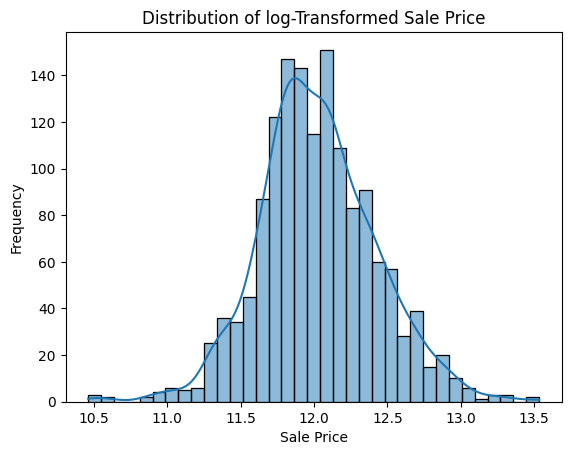

In [7]:
plt.figsize=(10,6)
sns.histplot(df['SalePrice'],kde=True)
plt.title('Distribution of log-Transformed Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

The target variable has been log-transformed to reduce skewness.  
The distribution now appears closer to normal, which is beneficial for regression models.

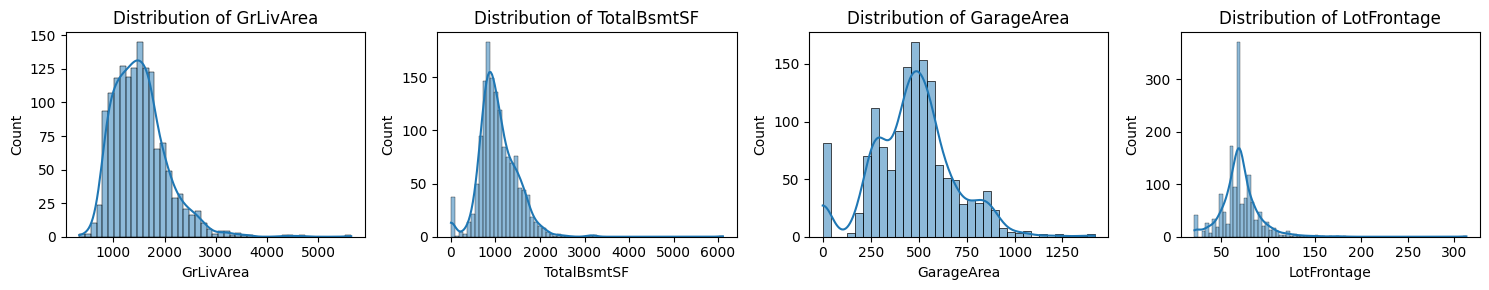

In [26]:
nums_cols=['GrLivArea','TotalBsmtSF','GarageArea','LotFrontage']
col_per_row=4
row=(len(nums_cols)+col_per_row-1)//col_per_row
fig,axes=plt.subplots(row,col_per_row,figsize=(15,3*row))  
axes=axes.flatten()
for i,col in enumerate(nums_cols):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
for j in range(i+1,len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


## Categorical Feature Analysis

Categorical variables represent different house characteristics such as neighborhood, building style, and quality ratings.

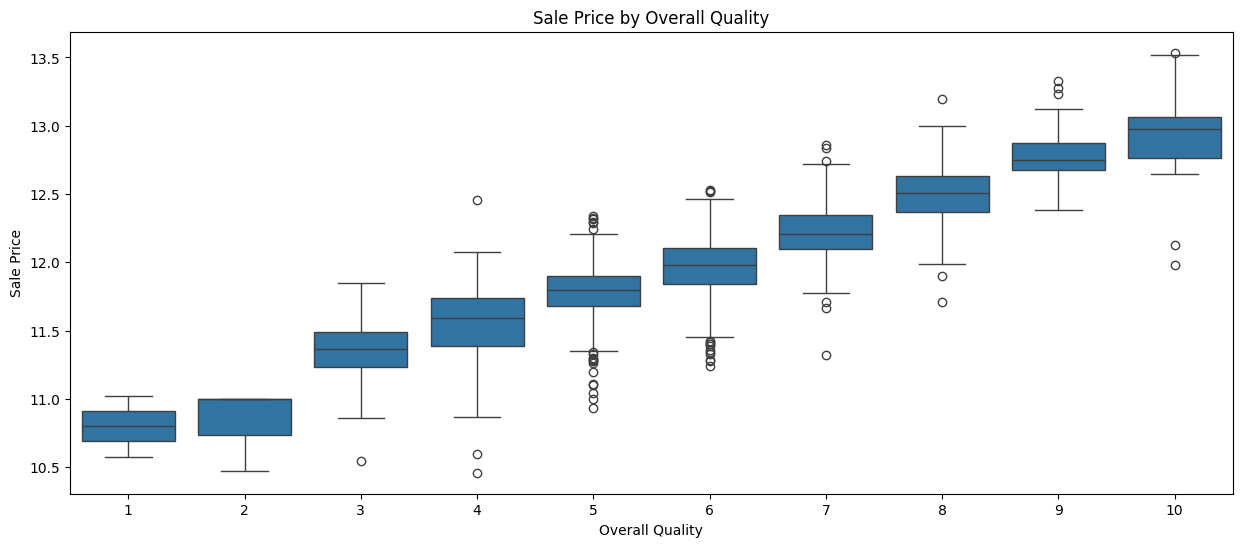

In [32]:
plt.figure(figsize=(15,6))
sns.boxplot(x='OverallQual',y='SalePrice',data=df)
plt.title('Sale Price by Overall Quality')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.show()

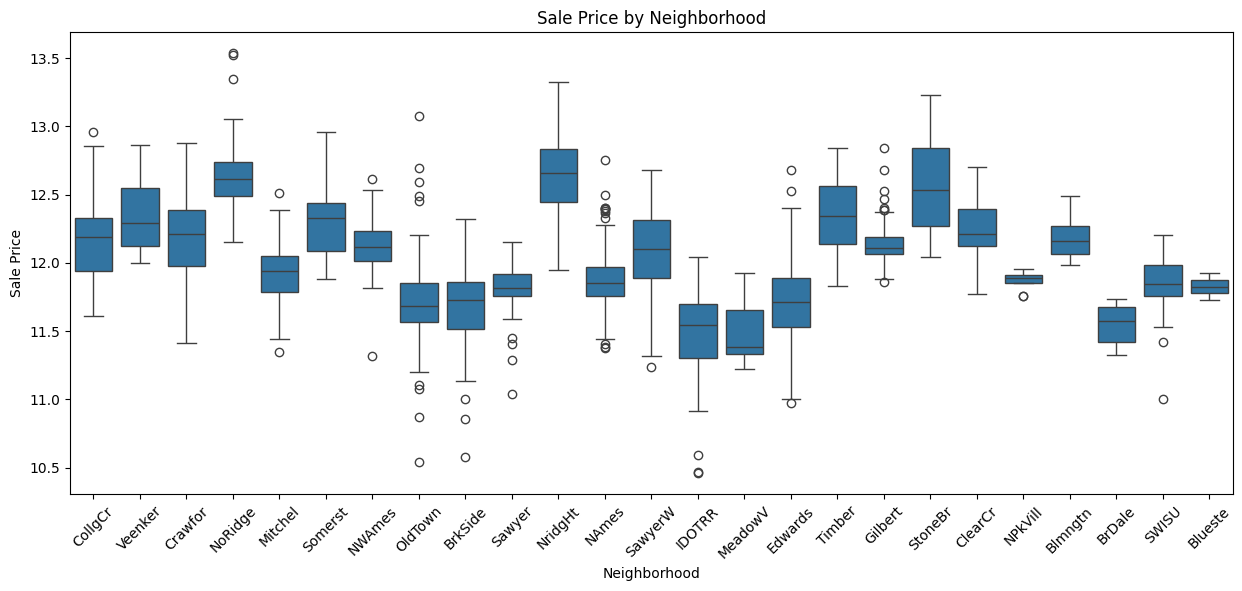

In [33]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Neighborhood',y='SalePrice',data=df)
plt.title('Sale Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)
plt.show()

## Correlation Analysis

Correlation analysis helps identify numerical features that have strong relationships with the target variable.

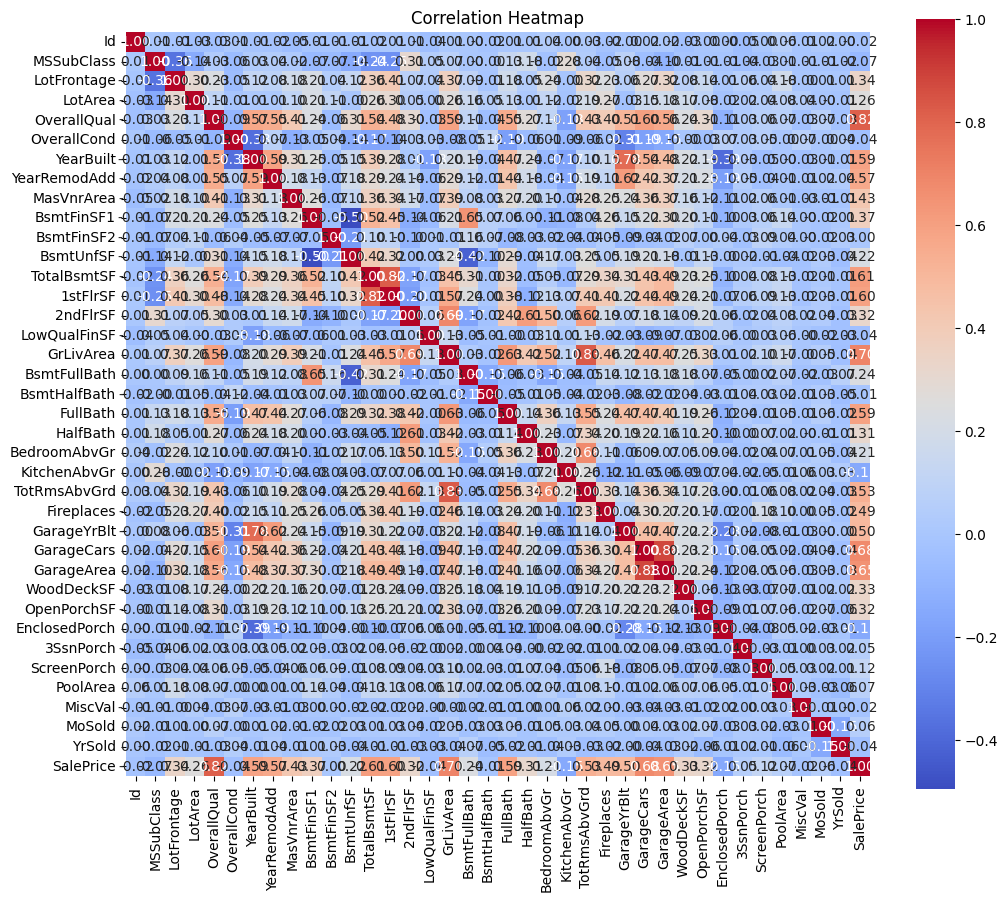

In [34]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',square=True)
plt.title('Correlation Heatmap')
plt.show()

In [35]:
corr['SalePrice'].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
Name: SalePrice, dtype: float64

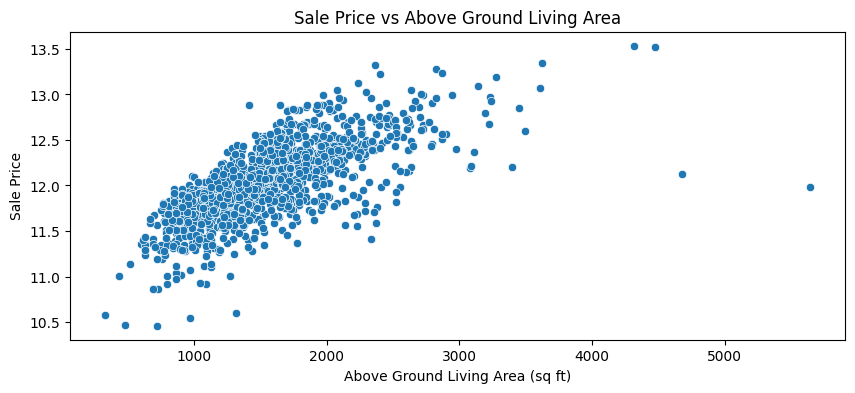

In [44]:
plt.figure(figsize=(10,4))
sns.scatterplot(x='GrLivArea',y='SalePrice',data=df)
plt.title('Sale Price vs Above Ground Living Area')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

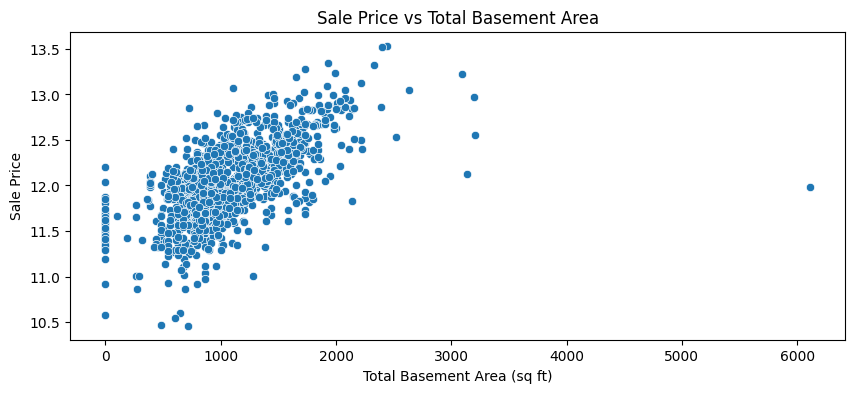

In [45]:
plt.figure(figsize=(10,4))
sns.scatterplot(x='TotalBsmtSF',y='SalePrice',data=df)
plt.title('Sale Price vs Total Basement Area')
plt.xlabel('Total Basement Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

In [47]:
df=df[df['GrLivArea']<4000]
df=df[df['TotalBsmtSF']<4000]
df.to_csv('C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Data/processed/cleaned_train.csv',index=False)

## Key Insights from EDA

• Overall house quality (`OverallQual`) shows strong correlation with house price.  
• Larger living area (`GrLivArea`) is associated with higher property prices.  
• Neighborhood location significantly impacts house prices.  
• Basement area and garage capacity also influence the final sale price.  
• Some outliers exist in large living area properties and should be investigated before modeling.
These insights will guide feature engineering and model development in the next stage of the project.